In [1]:
import json
import re

# Open and read file 
with open('corpus.json', 'r', encoding='utf-8') as file:
    content = file.read()

# Remove control characters using regex
cleaned_content = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', content)

try:
    data = json.loads(cleaned_content)
    print("JSON loaded successfully!")

except json.JSONDecodeError as e:
    print(f"Having trouble loading JSON: {e}")

    error_location = e.pos
    start = max(0, error_location - 50)
    end = min(len(cleaned_content), error_location + 50)
    print(f"Context around the error: '{cleaned_content[start:end]}'")


JSON loaded successfully!


In [3]:
from gensim.models import Word2Vec

corpus = [artigo['lema'] for artigo in data] 
model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=2, workers=4)


In [4]:
# Similaridade com a palavra "software"
similaridade_software = model.wv.most_similar("software", topn=10)
print("Similaridade com 'software':")
for palavra, score in similaridade_software:
    print(f"{palavra}: {score:.4f}")


Similaridade com 'software':
testing: 0.9992
capability: 0.9991
identify: 0.9990
create: 0.9990
effectively: 0.9990
could: 0.9989
enable: 0.9989
their: 0.9988
human: 0.9988
evaluation: 0.9988


In [ ]:
resultado_analogia = model.wv.most_similar(positive=["llm", "language"], negative=["developer"])
print("Analogy: llm + language - developer")
for word, score in resultado_analogia:
    print(f"{word}: {score:.4f}")


Analogy: engineer + token - developer
model: 0.9891
natural: 0.9827
text: 0.9824
large: 0.9811
task: 0.9805
performance: 0.9750
fine: 0.9748
style: 0.9743
transfer: 0.9730
arbitrary: 0.9722


In [13]:
analogy1 = model.wv.most_similar(positive=["transformer", "openai"], negative=["llm"])
print("Analogy: transformer + openai - llm")
print("Results:")
for word, score in analogy1:
    print(f"{word}: {score:.4f}")
print("\n")

analogy2 = model.wv.most_similar(positive=["prompt", "training"], negative=["dataset"])
print("Analogy: prompt + training - dataset")
print("Results:")
for word, score in analogy2:
    print(f"{word}: {score:.4f}")
print("\n")

analogy3 = model.wv.most_similar(positive=["artificial", "intelligence"], negative=["neural"])
print("Analogy: artificial + intelligence - neural")
print("Results:")
for word, score in analogy3:
    print(f"{word}: {score:.4f}")

Analogy: transformer + openai - llm
Results:
Speech: 0.9962
Sharma: 0.9960
Engineering: 0.9959
Workshop: 0.9958
Center: 0.9958
Grande: 0.9957
ACM: 0.9955
Computer: 0.9955
Computing: 0.9955
Learning: 0.9954


Analogy: prompt + training - dataset
Results:
well: 0.9990
enhance: 0.9988
various: 0.9988
utilize: 0.9988
architecture: 0.9988
potential: 0.9988
instruction: 0.9987
by: 0.9987
technique: 0.9987
example: 0.9987


Analogy: artificial + intelligence - neural
Results:
service: 0.9980
National: 0.9979
over: 0.9979
environment: 0.9979
current: 0.9979
long: 0.9979
Analysis: 0.9978
n: 0.9978
GB: 0.9978
without: 0.9978


# Plot

In [25]:
import re
from nltk.corpus import stopwords

# Certifique-se de baixar as stopwords (só precisa fazer uma vez)
import nltk
nltk.download('stopwords')
stopwords_en = set(stopwords.words("english"))

# Top N palavras mais frequentes do vocabulário treinado
top_n = 50
palavras_frequentes = sorted(
    model.wv.key_to_index, 
    key=lambda w: model.wv.get_vecattr(w, "count"), 
    reverse=True
)[:top_n]

# Filtra palavras com no mínimo 3 letras, apenas alfabéticas, e que não sejam stopwords
palavras_filtradas = [
    p for p in palavras_frequentes 
    if p.lower() not in stopwords_en
]

# Extrai vetores
vetores = [model.wv[p] for p in palavras_filtradas]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rafae\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


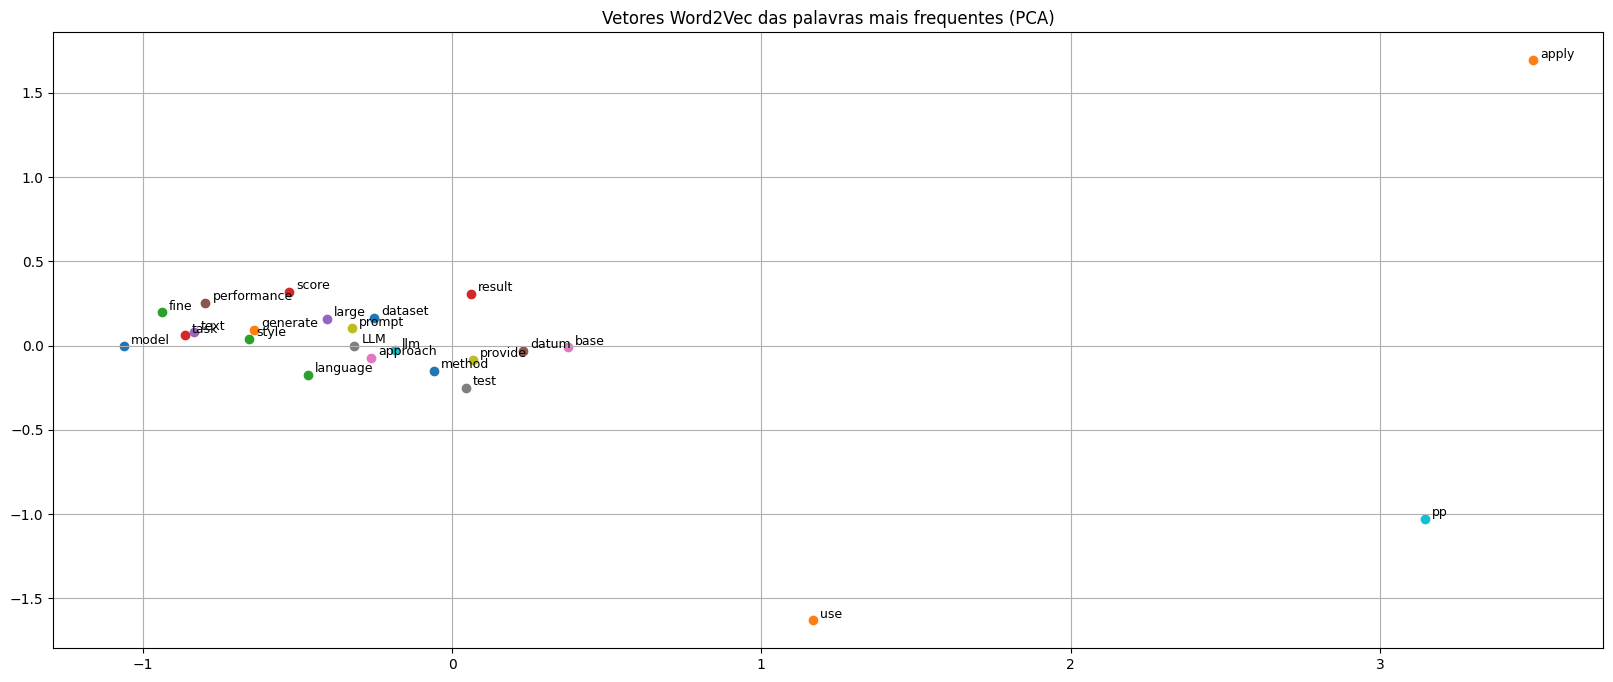

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduz a 2 dimensões
pca = PCA(n_components=2)
vetores_2d = pca.fit_transform(vetores)

# Plot
plt.figure(figsize=(20, 8))
for i, palavra in enumerate(palavras_filtradas):
    plt.scatter(*vetores_2d[i])
    plt.annotate(palavra, xy=vetores_2d[i], xytext=(5, 2), textcoords='offset points', fontsize=9)
plt.title("Vetores Word2Vec das palavras mais frequentes (PCA)")
plt.grid(True)
plt.show()
